# PPE Detection: Fine-Tuning YOLOv8s on Construction Site Safety Data

Fine-tunes a YOLOv8s model on the Roboflow Construction Site Safety
dataset (v30) for hardhat, mask, and safety-vest detection. Trains
on Colab T4, exports the best weights for use in the Gradio app.

## 1. Environment & Dependencies

In [ ]:
# Verify GPU is enabled
!nvidia-smi

Wed Jan 28 13:34:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics roboflow -q
print("Dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 57.3 MB/s eta 0:00:00
Dependencies installed!


## 2. Download Dataset from Roboflow

Set your Roboflow API key in the Colab environment before running 
this cell: **Tools → Settings → ... or** `os.environ["ROBOFLOW_API_KEY"] = "your_key"`. 
Get a key from [roboflow.com/settings/api](https://roboflow.com/settings/api).

In [ ]:
from roboflow import Roboflow

import os
rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
version = project.version(30)
dataset = version.download("yolov8")


print(f"\nDataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction-Site-Safety-30 in yolov8:: 100%|██████████| 1446/1446 [00:00<00:00, 5729.61it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Dataset downloaded to: /content/Construction-Site-Safety-30


In [ ]:
# Quick sanity check on the dataset
import yaml, glob

with open(f"{dataset.location}/data.yaml") as f:
    config = yaml.safe_load(f)

print(f"Classes ({len(config['names'])}): {config['names']}")
print(f"Train images: {len(glob.glob(f'{dataset.location}/train/images/*.jpg'))}")
print(f"Val images:   {len(glob.glob(f'{dataset.location}/valid/images/*.jpg'))}")
print(f"Test images:  {len(glob.glob(f'{dataset.location}/test/images/*.jpg'))}")

## 3. Train Model

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8s model
model = YOLO("yolov8s.pt")

# Train on PPE dataset
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    name="ppe_detector",
    patience=10,  # Early stopping if no improvement
    save=True,
    plots=True
)

print(f"\nTraining complete. Best weights at: runs/detect/ppe_detector/weights/best.pt")

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Construction-Site-Safety-30/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

## 4. Validate on Test Set

In [ ]:
# Validate on test set
metrics = model.val()

print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall: {metrics.box.mr:.3f}")

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 11,135,259 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1462.0±753.9 MB/s, size: 98.9 KB)
val: Scanning /content/Construction-Site-Safety-30/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 36.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.3it/s 3.5s
                   all        114        733      0.802      0.492      0.614      0.423
             Excavator         10         12      0.819      0.667      0.794       0.67
                Gloves         11         25      0.716       0.36      0.411      0.207
               Hardhat         42         79      0.942      0.612      0.741       0.53
                Ladder          8         10       0.58        0.7      0.664      0.452
                  Mask        

## 5. Sample Predictions

In [ ]:
import glob
from IPython.display import Image, display

# Load the best trained model
best_model = YOLO("runs/detect/ppe_detector/weights/best.pt")

# Get some test images
test_images = glob.glob(f"{dataset.location}/test/images/*.jpg")[:3]

# Run inference
for img_path in test_images:
    results = best_model(img_path, save=True, project="test_results", name="predictions")

# Display results
print("\nSample Predictions:\n")
for img in glob.glob("test_results/predictions/*.jpg")[:3]:
    display(Image(filename=img, width=500))
    print("---")


image 1/1 /content/Construction-Site-Safety-30/test/images/Image36_jpg.rf.137e9f15ce037d4f965dd8b538091cd5.jpg: 640x640 6 Hardhats, 1 Mask, 1 NO-Hardhat, 3 NO-Masks, 1 NO-Safety Vest, 5 Persons, 1 vehicle, 16.3ms
Speed: 3.0ms preprocess, 16.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/test_results/predictions

image 1/1 /content/Construction-Site-Safety-30/test/images/2009_000059_jpg.rf.fdadf92b3365ec373f467210a8e174d5.jpg: 448x640 1 NO-Hardhat, 1 NO-Mask, 1 NO-Safety Vest, 1 Person, 50.0ms
Speed: 1.7ms preprocess, 50.0ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/test_results/predictions2

image 1/1 /content/Construction-Site-Safety-30/test/images/construction-2-_mp4-13_jpg.rf.36956cedb12777fcc7a4598371a735f3.jpg: 384x640 2 Excavators, 1 dump truck, 1 wheel loader, 46.1ms
Speed: 1.9ms preprocess, 46.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 6

## 6. Export Trained Weights

In [ ]:
from google.colab import files
import shutil

# Copy best model to easy location
shutil.copy("runs/detect/ppe_detector/weights/best.pt", "ppe_detector_best.pt")

# Download it
print("Downloading trained model...")
files.download("ppe_detector_best.pt")

print("\nDone.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done.


## 7. Training Curves & Confusion Matrix

Training Results:



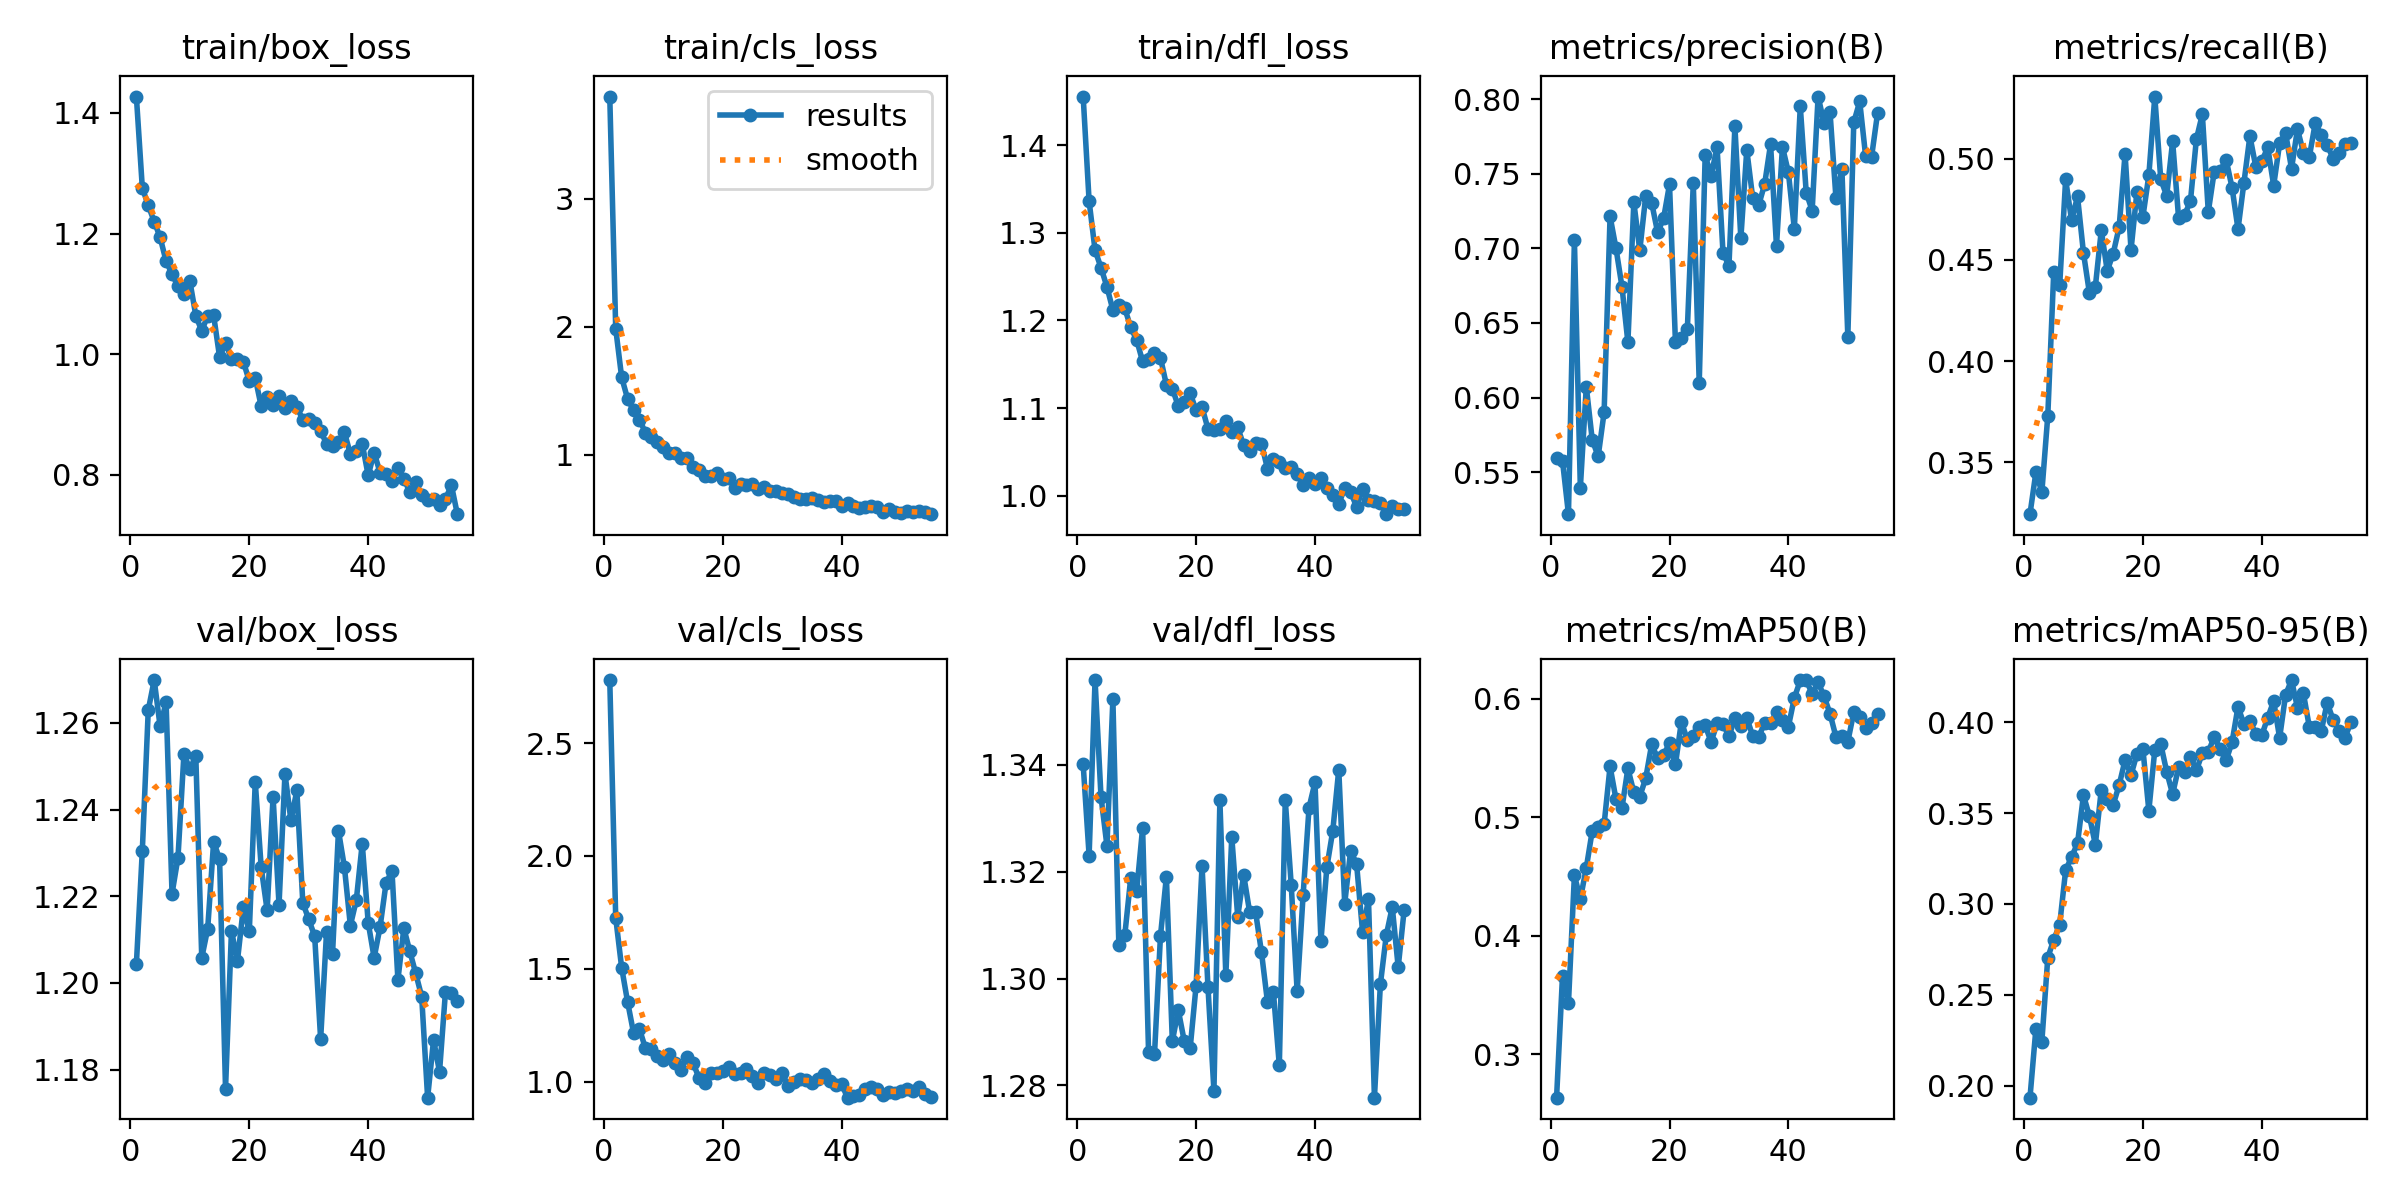


Confusion Matrix:



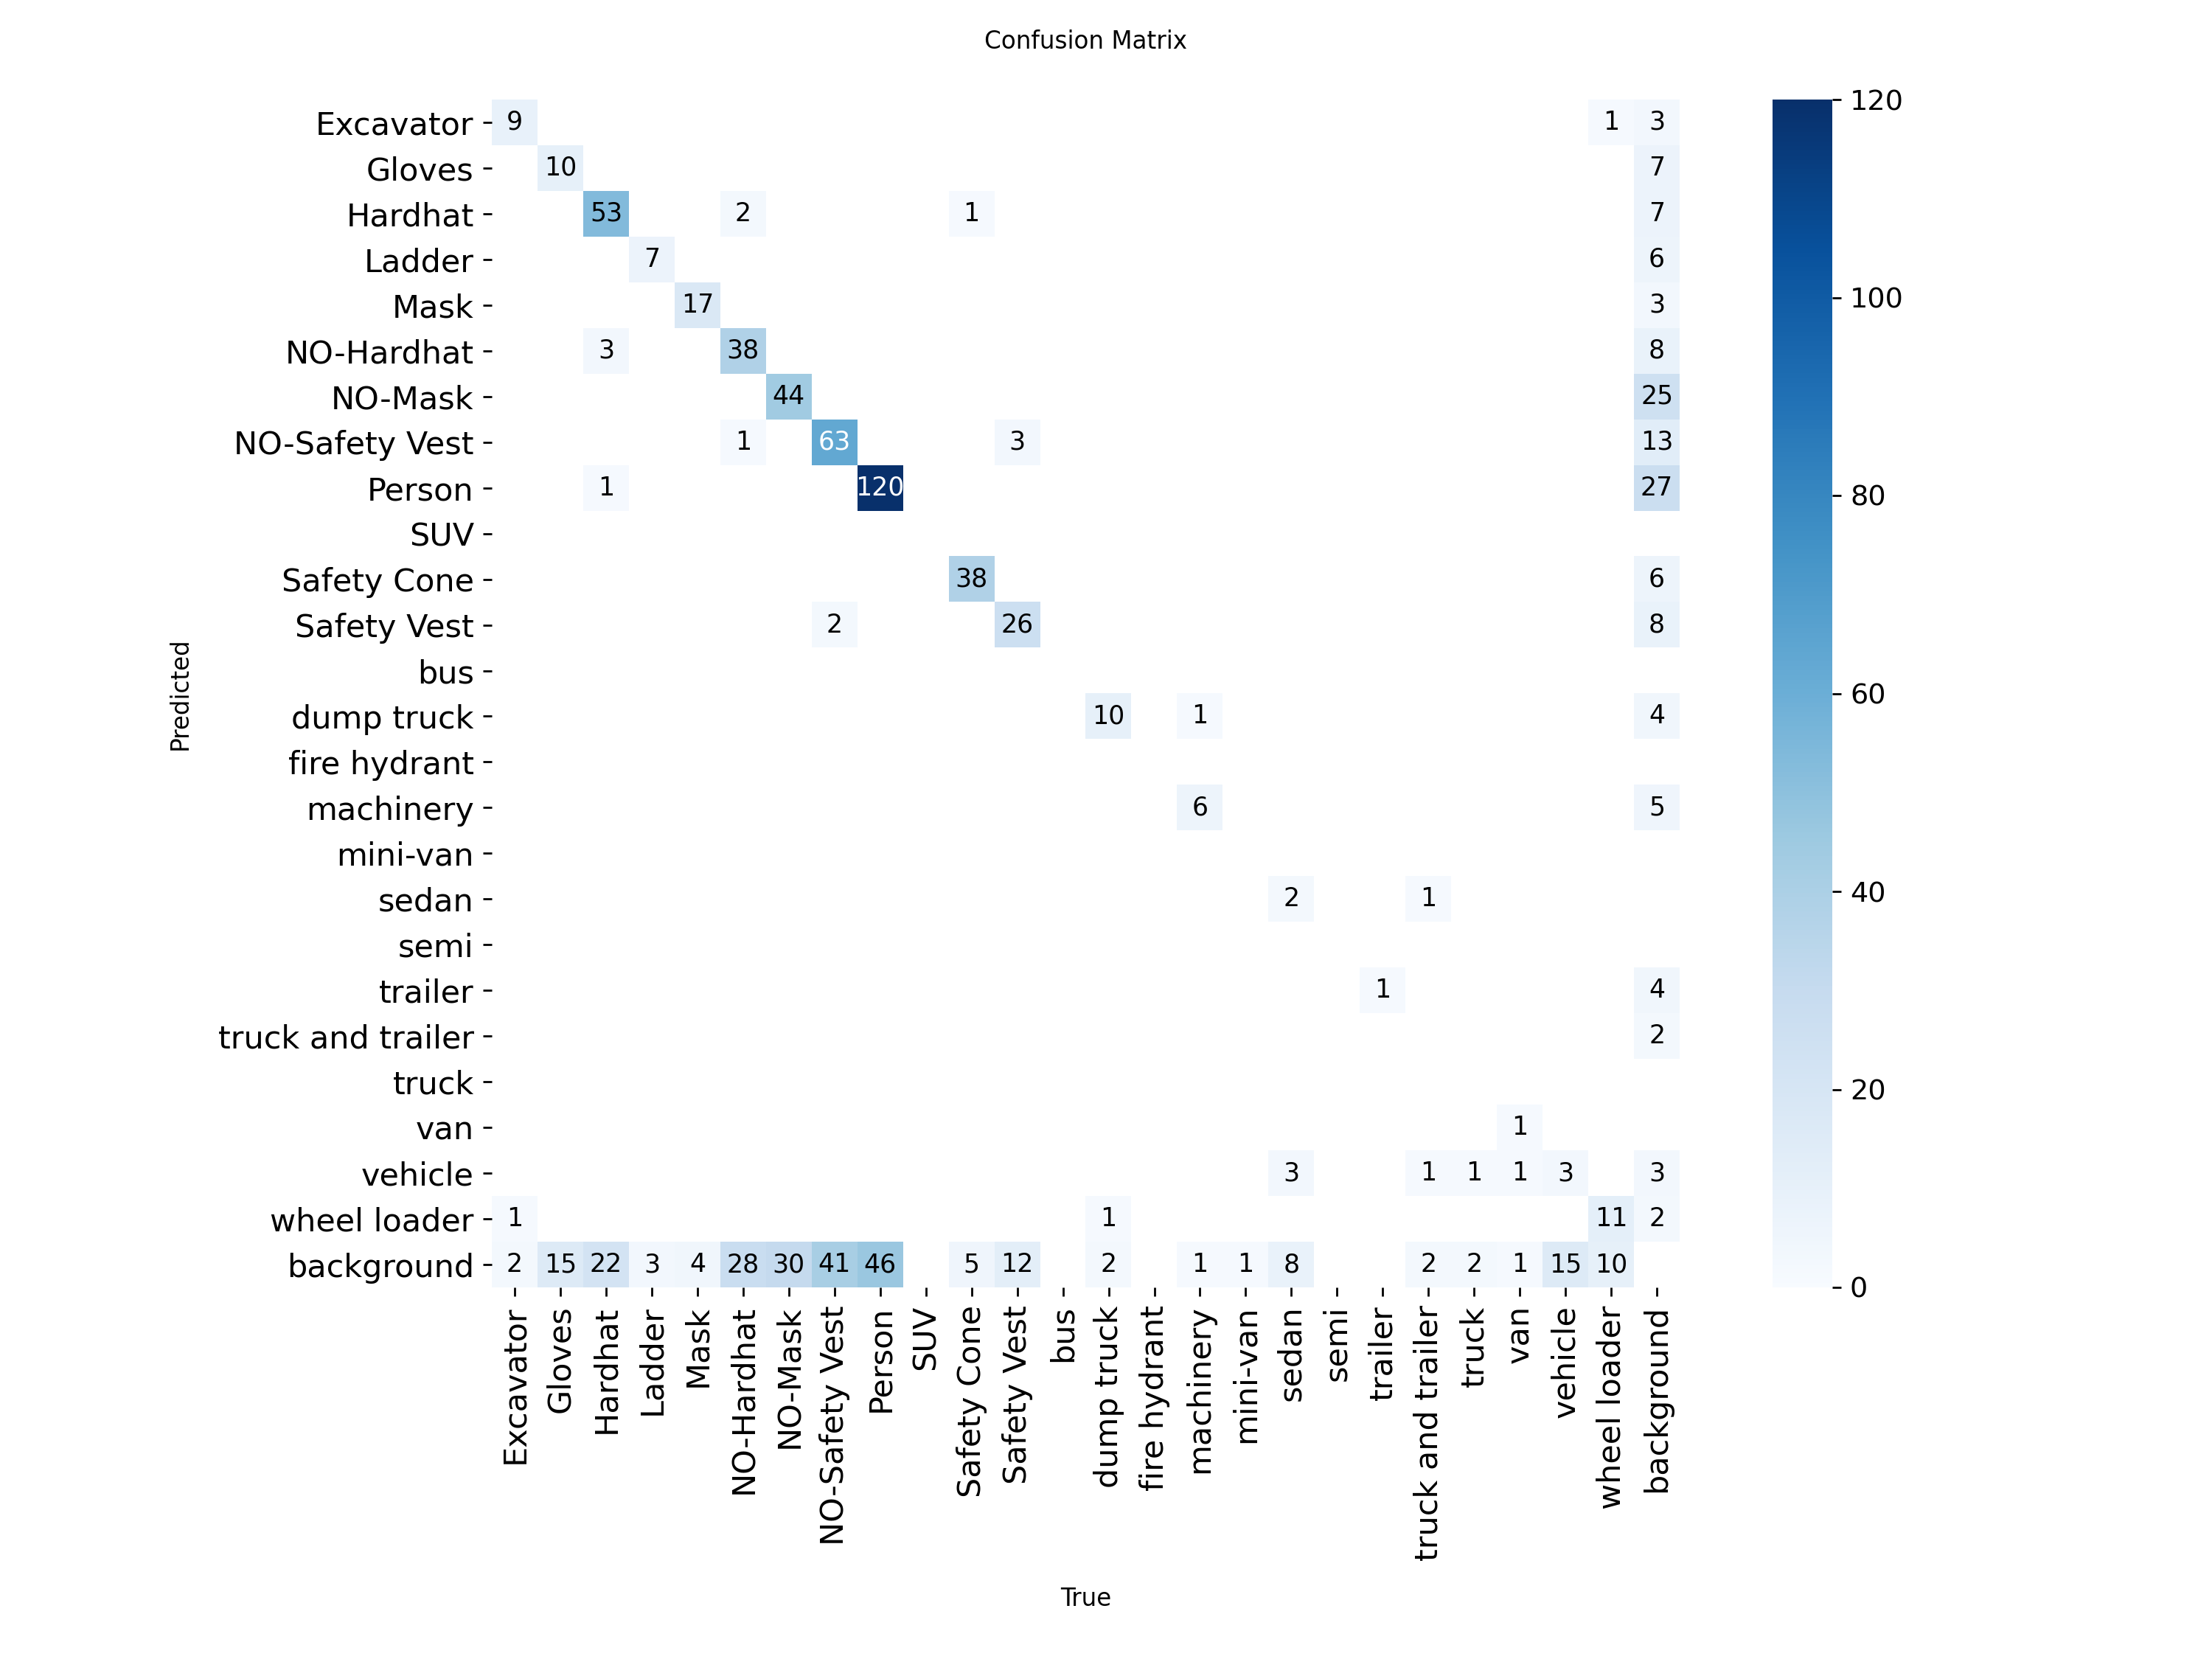

In [ ]:
# Display training curves
from IPython.display import Image, display

print("Training Results:\n")
display(Image(filename="runs/detect/ppe_detector/results.png", width=800))

print("\nConfusion Matrix:\n")
display(Image(filename="runs/detect/ppe_detector/confusion_matrix.png", width=600))